In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/satishgour/eng-nep/nepali.txt
/kaggle/input/datasets/satishgour/eng-nep/english.txt


In [26]:
# ================================
# STEP 1 : LOAD DATASET
# ================================

import pandas as pd

# Load English sentences
with open("/kaggle/input/datasets/satishgour/eng-nep/english.txt", "r", encoding="utf-8") as f:
    english_sentences = f.readlines()

# Load Nepali sentences
with open("/kaggle/input/datasets/satishgour/eng-nep/nepali.txt", "r", encoding="utf-8") as f:
    nepali_sentences = f.readlines()

# Remove newline characters
english_sentences = [x.strip() for x in english_sentences]
nepali_sentences = [x.strip() for x in nepali_sentences]

# Create DataFrame
df = pd.DataFrame({
    "source": english_sentences,
    "target": nepali_sentences
})

# Show dataset info
print("Total sentence pairs:", len(df))

# Show first 5 rows
df.head()

Total sentence pairs: 14282


,source,target
0,A person gains their place in society based on...,मानका आधारमा व्यक्ति समाजमा आफ्नो स्थान पाउँछ।
1,Her trust was honored.,उसको विश्वासको मान गरियो।
2,Honor should not be dishonored.,मानलाई कुण्ठित नगर्नु पर्छ।
3,"When it comes to honor, they don’t make any co...","जब मानको कुरा आउँछ, तिनीहरूले कुनै सम्झौता गर्..."
4,A person’s honor is a measure of their respect...,व्यक्तिको मान समाजमा उसको इज्जतको मानक हो।


In [27]:
# ================================
# STEP 2 : CLEAN + SPLIT DATASET
# ================================

from sklearn.model_selection import train_test_split

# Remove empty rows
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove very short sentences
df = df[
    (df["source"].str.len() > 2) &
    (df["target"].str.len() > 2)
]

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset size after cleaning:", len(df))

# Train-Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

# Validation split from training data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42
)

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

# Display samples
train_df.head()

Dataset size after cleaning: 13940

Training samples: 11291
Validation samples: 1255
Testing samples: 1394


,source,target
3757,"""What do you mean by this?""",“यस्तो भन्नाले ?'
6300,"""I also had a hard time holding myself back. I...",आफूलाई पनि मन थाम्न सकस भयो । पटक्कै निद्रा ला...
4212,"Oil medium is ubiquitous, but my canvases refl...",तेल-माध्यम सर्वव्यापी छ तर मेरा क्यानभास स्थान...
9115,"After reaching the street, I began to think ab...",बाटामा आइपुगेपछि सोच्न थालें बास्तबमा बरीको सन...
11944,I noticed some difference in the color of the ...,मैले पुतलीको पंखको रंगमा केही भिन्नता देखे।


In [28]:
# ================================
# STEP 3 : HUGGINGFACE DATASET
# ================================

from datasets import Dataset, DatasetDict

# Convert pandas dataframe to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Create DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

# Show dataset structure
print(dataset)

# Show one sample
print("\nSample Data:")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['source', 'target', '__index_level_0__'],
        num_rows: 11291
    })
    validation: Dataset({
        features: ['source', 'target', '__index_level_0__'],
        num_rows: 1255
    })
    test: Dataset({
        features: ['source', 'target', '__index_level_0__'],
        num_rows: 1394
    })
})

Sample Data:
{'source': '"What do you mean by this?"', 'target': "“यस्तो भन्नाले ?'", '__index_level_0__': 3757}


In [29]:
# ================================
# STEP 4 : LOAD MODEL + TOKENIZER
# ================================

from transformers import MarianMTModel, MarianTokenizer

# Pretrained MarianMT model
model_name = "Helsinki-NLP/opus-mt-en-mul"

# Load tokenizer
tokenizer = MarianTokenizer.from_pretrained(model_name)

# Load model
model = MarianMTModel.from_pretrained(model_name)

print("Model and Tokenizer Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model and Tokenizer Loaded Successfully


In [31]:
# ================================
# STEP 5 : TOKENIZATION (FIXED)
# ================================

max_input_length = 64
max_target_length = 64

def preprocess_function(examples):

    # Tokenize source (English)
    model_inputs = tokenizer(
        examples["source"],
        max_length=max_input_length,
        truncation=True,
        padding="max_length"
    )

    # Tokenize target (Nepali)
    labels = tokenizer(
        text_target=examples["target"],
        max_length=max_target_length,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# Apply tokenization
tokenized_dataset = dataset.map(preprocess_function)

print(tokenized_dataset)

# Show tokenized example
print("\nTokenized Sample:")
print(tokenized_dataset["train"][0])

Map:   0%|          | 0/11291 [00:00<?, ? examples/s]

Map:   0%|          | 0/1255 [00:00<?, ? examples/s]

Map:   0%|          | 0/1394 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'target', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 11291
    })
    validation: Dataset({
        features: ['source', 'target', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1255
    })
    test: Dataset({
        features: ['source', 'target', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1394
    })
})

Tokenized Sample:
{'source': '"What do you mean by this?"', 'target': "“यस्तो भन्नाले ?'", '__index_level_0__': 3757, 'input_ids': [123, 6402, 67, 23, 1760, 71, 72, 2255, 0, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 64109, 6

In [35]:
# ================================
# STEP 6 : TRAINER SETUP (FIXED)
# ================================

from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# Data collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

# Training arguments
training_args = Seq2SeqTrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    learning_rate=3e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    weight_decay=0.01,

    save_total_limit=2,

    num_train_epochs=10,

    predict_with_generate=True,

    fp16=True,

    logging_steps=500,

    save_strategy="epoch",

    logging_dir="./logs"
)

# Trainer
trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,

    data_collator=data_collator
)

print("Trainer Ready")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer Ready


In [36]:
# ================================
# STEP 7 : START TRAINING
# ================================

print("Training Started...\n")

trainer.train()

print("\nTraining Completed")

Training Started...



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,2.045862,1.688912
2,1.579500,1.541974
3,1.375051,1.472180
4,1.203014,1.440303
5,1.100301,1.417386
6,0.996884,1.395329
7,0.910149,1.395828
8,0.862781,1.401703
9,0.829264,1.404499
10,0.781878,1.409305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [37]:
# ================================
# STEP 8.1 : SAVE MODEL
# ================================

model.save_pretrained("./english-nepali-model")

tokenizer.save_pretrained("./english-nepali-model")

print("Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully


In [38]:
# ================================
# STEP 8.2 : TRANSLATION FUNCTION
# ================================

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

def translate(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    translated_tokens = model.generate(
        **inputs,
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    translated_text = tokenizer.decode(
        translated_tokens[0],
        skip_special_tokens=True
    )

    return translated_text

# Test Translation
sample = "Machine learning is very useful."

translation = translate(sample)

print("English :", sample)
print("Nepali  :", translation)

English : Machine learning is very useful.
Nepali  : मेसिन शिक्षा धेरै उपयोगी छ।


In [39]:
# ================================
# STEP 8.3 : GENERATE PREDICTIONS
# ================================

predictions = []
references = []

for sample in dataset["test"]:

    pred = translate(sample["source"])

    predictions.append(pred)

    references.append(sample["target"])

print("Total Predictions:", len(predictions))

Total Predictions: 1394


In [40]:
# ================================
# STEP 8.4 : BLEU SCORE
# ================================

from evaluate import load

bleu_metric = load("sacrebleu")

references_bleu = [[ref] for ref in references]

bleu = bleu_metric.compute(
    predictions=predictions,
    references=references_bleu
)

print("BLEU Score:", bleu["score"])

BLEU Score: 17.203827750171286


In [41]:
# ================================
# STEP 8.5 : RESULT TABLE
# ================================

import pandas as pd

results_df = pd.DataFrame({

    "English": [x["source"] for x in dataset["test"]],

    "Actual Nepali": references,

    "Predicted Nepali": predictions
})

results_df.head(20)

,English,Actual Nepali,Predicted Nepali
0,It has launched the International Space Statio...,यसले अन्तरिक्षमा वैज्ञानिक अनुसन्धान तथा खगोल ...,यसले वैज्ञानिक तथा अस्ट्रोनिक अध्ययनका लागि अन...
1,The heartbeat is due to its contraction and re...,यसका खुम्चाइ र फुकाइका कारण मुटुमा धड्कन सिर्ज...,मुटुको कच्चा र विश्राम गर्दा हुन्छ।
2,The direction of the answer must always be clear.,उत्तरको दिशा सधैं स्पष्ट हुनु पर्छ।,उत्तरको दिशा सधैं स्पष्ट हुनुपर्छ।
3,"By befriending death and time, life can be dir...",काल र समयसँग मित्रता गरेर जीवनलाई सकारात्मक दि...,काल र समयको साथी गरेर सकारात्मक मार्गतर्फ जीवन...
4,I have allocated Rs. 8 billion 390 million for...,प्रारम्भिक बाल शिक्षा देखि कक्षा पाँचसम्मका ती...,दिनको मध्य भोजन कार्यक्रमका लागि रु. ८ अर्ब ३९...
5,Pine trees are found abundantly in the forest.,सालको रुख जंगलमा धेरै पाइन्छ।,सालको रूख जंगलमा धेरै पाइन्छ।
6,The direction of the answer can be easily unde...,उत्तरको दिशा सजिलै बुझ्न सकिन्छ।,उत्तरको दिशा सजिलै बुझ्न सकिन्छ।
7,We are using the energy carried by light waves...,"हामीले प्रकाशका तरङ्ग, घाममा न्यानो दिने तरङ्ग...","प्रकाश तरङ्गले बोकेको शक्ति, सूर्यबाट तापको तर..."
8,Copyright will be protected and regulated.,प्रतिलिपि अधिकारको संरक्षण र नियमन गरिनेछ।,अधिकारको रक्षा संरक्षण र नियमन गरिनेछ।
9,Fossils are only found in sedimentary rock.,जीवावशेष पत्र चट्टानमा मात्र पाइन्छ।,फोसहरू सेजिडमरी चट्टानमा मात्र पाइन्छन्।


In [42]:
# ================================
# STEP 8.6 : SAVE CSV
# ================================

results_df.to_csv(
    "translation_results.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


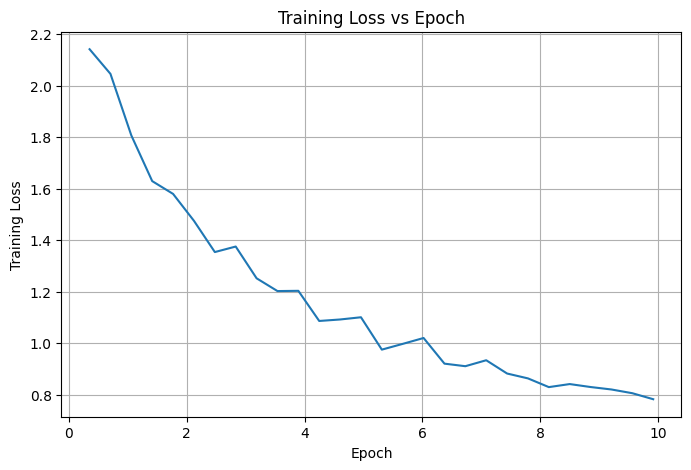

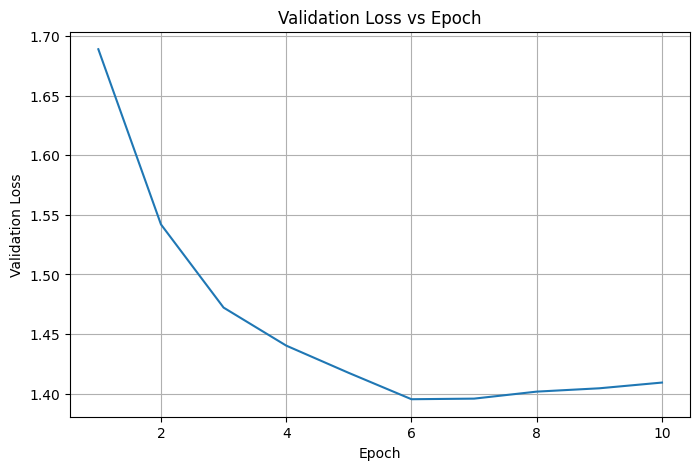

In [43]:
# ================================
# STEP 8.7 : LOSS GRAPHS
# ================================

import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = []
eval_loss = []

train_epochs = []
eval_epochs = []

for log in logs:

    if "loss" in log:
        train_loss.append(log["loss"])
        train_epochs.append(log["epoch"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_epochs.append(log["epoch"])

# Training Loss Graph
plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_loss)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss vs Epoch")

plt.grid(True)

plt.show()

# Validation Loss Graph
plt.figure(figsize=(8,5))

plt.plot(eval_epochs, eval_loss)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title("Validation Loss vs Epoch")

plt.grid(True)

plt.show()

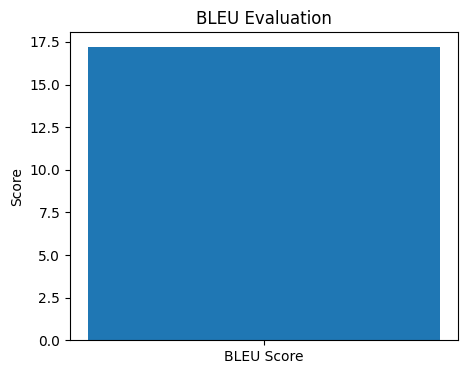

In [44]:
# ================================
# STEP 8.8 : BLEU GRAPH
# ================================

plt.figure(figsize=(5,4))

plt.bar(
    ["BLEU Score"],
    [bleu["score"]]
)

plt.ylabel("Score")

plt.title("BLEU Evaluation")

plt.show()

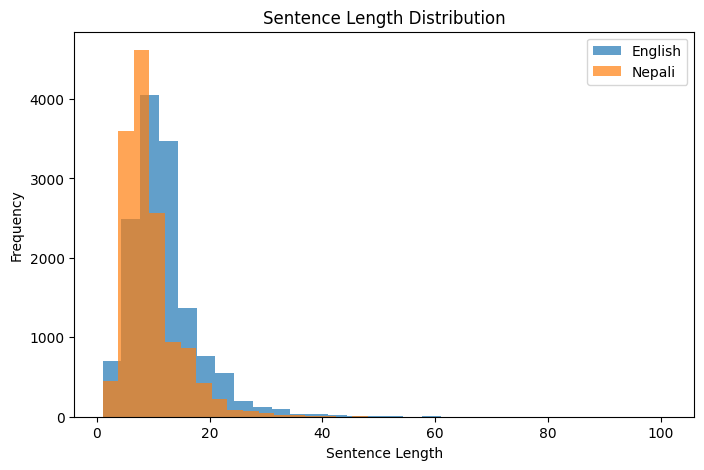

In [45]:
# ================================
# STEP 8.9 : DATASET ANALYSIS
# ================================

source_lengths = [
    len(x.split())
    for x in df["source"]
]

target_lengths = [
    len(x.split())
    for x in df["target"]
]

plt.figure(figsize=(8,5))

plt.hist(
    source_lengths,
    bins=30,
    alpha=0.7,
    label="English"
)

plt.hist(
    target_lengths,
    bins=30,
    alpha=0.7,
    label="Nepali"
)

plt.xlabel("Sentence Length")

plt.ylabel("Frequency")

plt.title("Sentence Length Distribution")

plt.legend()

plt.show()

In [46]:
# ================================
# STEP 8.10 : SAVE TRAINING LOGS
# ================================

log_df = pd.DataFrame(logs)

log_df.to_csv(
    "training_logs.csv",
    index=False
)

print("Training Logs Saved")

Training Logs Saved


In [47]:
# ================================
# ZIP TRAINED MODEL
# ================================

import shutil

# Create zip file
shutil.make_archive(
    "english-nepali-model",
    'zip',
    "./english-nepali-model"
)

print("Model ZIP file created successfully")

Model ZIP file created successfully
